# Quantum Phase Estimation Problem

In [ ]:
!pip install qiskit
!pip install qiskit_aer
!pip install pylatexenc
!pip install qiskit_algorithms

In [ ]:
# Function for plotting quantum circuit
def qplot(x):
  return x.draw('mpl', initial_state = True, fold=False, scale = 0.7)

In [ ]:
import numpy as np
from qiskit import QuantumRegister, QuantumCircuit, ClassicalRegister, transpile
from qiskit.circuit.library import QFT, TGate

from qiskit_aer import QasmSimulator
from qiskit.visualization import plot_histogram

# What is the Problem?
> **Input:**
A quantum circuit implementing an operator $U$, and an eigenstate $|\psi\rangle $ with corresponding eigenvalue $e^{2\pi i\omega}$.
$$U|\psi\rangle = e^{2\pi i\omega} |\psi\rangle$$

> **Problem:** Obtain a good estimate for $\omega$.


# Example: $T$ gate
Let me consider as an input $T$ gate has been given and its controlled gate is also available.

\begin{eqnarray}
    T = \begin{pmatrix}
        1 & 0 \\
        0 & e^{\frac{i\pi}{4}}
    \end{pmatrix}    
\end{eqnarray}
where its eigenstate and eigenvalues are

$$    T |0\rangle = |0\rangle, \qquad   T |1\rangle = e^{\frac{i\pi}{4}} |1\rangle $$

Since QPE will give us
\begin{eqnarray}
    T |\psi\rangle = e^{2\pi i \theta} |\psi\rangle
\end{eqnarray}
where $|\psi\rangle $ for this case is $|1\rangle$. We expect to find:
\begin{eqnarray}
    2\pi i \theta = \frac{i\pi}{4} \to  \theta = \dfrac{1}{8}
\end{eqnarray}



In [ ]:
# Building the controlled-T gate
ct = TGate().control(1)

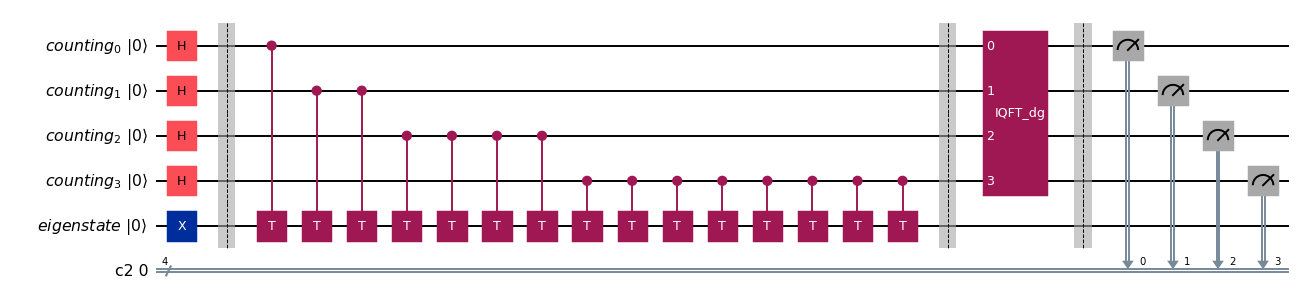

In [ ]:
# n: Number of qubits
n = 4
# Create two different register, it can help us to apply gate easire
q1 = QuantumRegister(n,name='counting')
q2 = QuantumRegister(1,name = 'eigenstate')
c = ClassicalRegister(n) # Classical register for saving the measurement result
qc = QuantumCircuit(q1,q2,c)
qc.x(q2[0])
qc.h(range(n))
qc.barrier()

reps = 1
for i in range(n):
  for j in range(reps):
    qc.append(ct, [q1[i],q2[0]])
  reps *= 2
qc.barrier()


qft_inv = QFT(num_qubits=n, inverse=True)
qc = qc.compose(qft_inv)
qc.barrier()

for i in range(n):
    qc.measure(q1[i],c[i])


qplot(qc)

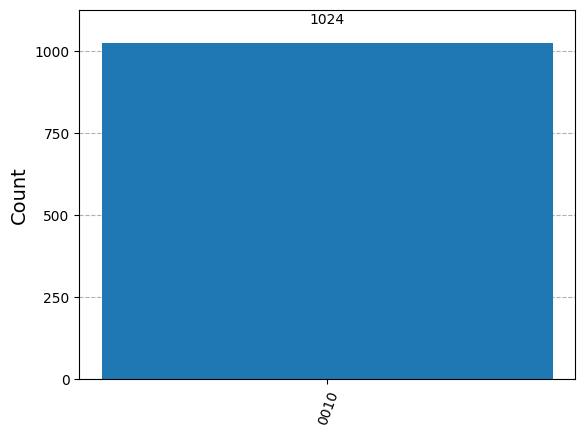

In [ ]:
result = QasmSimulator().run(transpile(qc, QasmSimulator()),shots=1024).result()
count = result.get_counts()
plot_histogram(count)

In [ ]:
print(count)

{'0010': 1024}


In [ ]:
result = []
for key in count.keys():
    result.append(key)

In [ ]:
result

['0010']

In [ ]:
result_dec = int(result[0],2)
result_dec

2

$$ 0010\equiv 2 = 2^4 \theta \to \theta = \dfrac{2}{16} = \dfrac{1}{8}$$

In [ ]:
theta = (result_dec)/2**n
theta

0.125